Direct shear experiment
Names: Andre and Wen
Sample: salt powder 
normal load: starting at 1MPa, 
shear speed: ????

AE: passive
ch1: PZT
ch2: LDV

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [70]:
dirc = '/Volumes/DirectShear/Active+TTL5V/'
fname = 'Active_TTL5v_TEST_pulse_width_1us_000.csv'
data = pd.read_csv(dirc+fname, skiprows=8, header=0, names=['time', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6'], sep=';')
timestamp = pd.read_csv(dirc+fname, skiprows=1, header=0,nrows=1)

In [71]:
data

,time,ch1,ch2,ch3,ch4,ch5,ch6
0,-0.0005,0.005686,-0.008676,-0.009645,0.002994,0.000568,-0.004723
1,-0.0005,0.005123,-0.001765,-0.007166,-0.000718,-0.000741,-0.005643
2,-0.0005,0.006961,-0.001912,-0.001364,-0.002598,0.003088,-0.005891
3,-0.0005,0.006863,-0.010735,-0.001289,-0.006978,0.002594,-0.007929
4,-0.0005,0.006912,-0.002647,-0.002430,0.001707,0.001309,-0.004350
...,...,...,...,...,...,...,...
49995,0.0045,0.007083,-0.005931,0.005653,-0.001262,0.001581,-0.006761
49996,0.0045,0.007377,-0.000466,-0.000669,0.001435,0.002495,0.002635
49997,0.0045,0.009167,-0.004583,-0.001289,-0.000272,-0.002100,-0.002908
49998,0.0045,0.009191,-0.007279,-0.002901,0.002648,0.001557,-0.006935


In [72]:
timestamp = pd.read_csv(dirc+fname, skiprows=1,names=['timestamp'],nrows=1)
timestamp.timestamp

0    2026-09-09 15:30:42 627m
Name: timestamp, dtype: object

In [73]:
data.time[2]-data.time[1]

9.999999999994822e-08

Text(0, 0.5, 'Voltage [mV]')

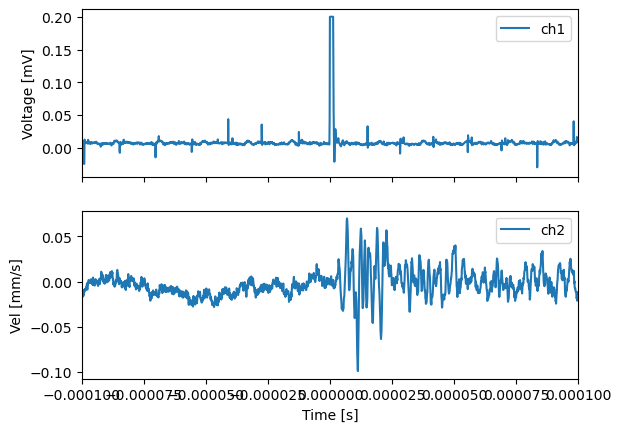

In [74]:
plt.close()
fig, axs = plt.subplots(2, sharex=True)
data.plot.line(x='time', y='ch1', ax=axs[0])
data.plot.line(x='time', y='ch2', ax=axs[1])
axs[0].set_xlim(-0.0001, 0.0001)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Vel [mm/s]')
axs[0].set_ylabel('Voltage [mV]')

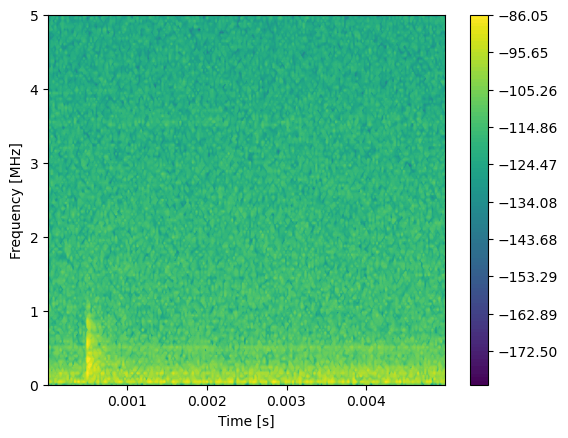

In [75]:
from labseis import signal

dt =data.time[2]-data.time[1]

ff, tt, sxx = signal.spectrogram(data.ch2, fs=int(1/dt))
# Example function
# ff, tt = np.meshgrid(ff, tt)
pxx = 10*np.log10(sxx)

# Plot
fig, ax = plt.subplots()

# Contour plot
levels = np.linspace(pxx.min(), pxx.max(), 100)
cs = ax.contourf(tt, ff/1e6, pxx, levels=levels[:100], cmap="viridis")
# cs = ax.imshow(pxx, aspect='auto', cmap="viridis")

# Log scale for y-axis
# ax.set_yscale("log")
# ax.set_ylim(0,5000)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [MHz]')

# ax.set_xlim(0,10)

# Add colorbar
fig.colorbar(cs, ax=ax)

plt.show()

In [76]:
# Compute pulse length for ch1 based on amplitude > 100 mV
threshold_mv = 200/1e3  # mV
pulse_samples = (data['ch1'].abs() == threshold_mv).sum()
print(f"Number of samples with |ch1| > {threshold_mv} mV: {pulse_samples}")
# Optionally, convert to time duration
dt = data.time.iloc[2] - data.time.iloc[1]
pulse_duration = pulse_samples * dt
print(f"Pulse duration: {pulse_duration:.6e} seconds")

Number of samples with |ch1| > 0.2 mV: 14
Pulse duration: 1.400000e-06 seconds


In [ ]:
# 40 us - 100 us
# 5 us - 10 us
# 1.5 us - 1 us

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'time after:                  timestamp\n0  2026-09-09 15:30:42 627m s, experiment: PSM111, block: 1')

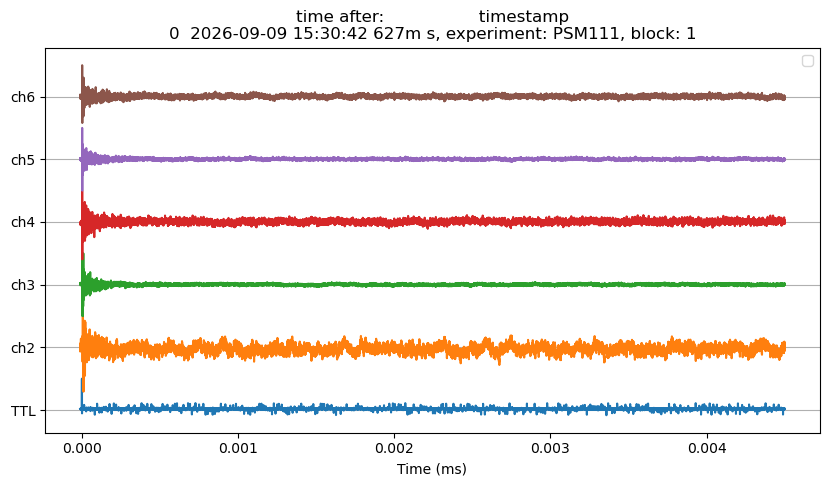

In [86]:
from labseis import wiggles
AE_stacked_filtered = data[['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6']].to_numpy().T
t = data.time.to_numpy()
channel_list = ['TTL', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6']
idx_t = (t>-0.00001)&(t<1)
fig, ax = wiggles(AE_stacked_filtered[:,idx_t], t[idx_t], np.arange(6), scale=0.5, scalebar=False)
ax.grid(axis='y')
ax.set_yticks(np.arange(6))
ax.set_yticklabels(channel_list[:6])
ax.set_xlabel('Time (ms)')
plt.title(f'time after:{timestamp} s, experiment: PSM111, block: 1')